# Analyzing NYC Citi Bike Trips: Patterns and Insights

**Vannessa Yoanita Oktorio Naibaho**

## 0. Setup & Configuration

### 0.1 Import Libraries
- Library yang digunakan untuk proses analisis data, visualisasi, dan koneksi ke BigQuery.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.cloud import bigquery

sns.set_theme(style="whitegrid")

# palette utama
palette = sns.color_palette("YlOrBr", n_colors=10)
sns.set_palette(palette)

# warna utama
PRIMARY = "#FFB000"
ACCENT  = "#FF8C00"

client = bigquery.Client()

### 0.2 Data Source Connection
- Melakukan autentikasi dan koneksi ke Google BigQuery sebagai sumber data.

In [2]:
# login
auth.authenticate_user()

# set project
!gcloud config set project citibike-analysis-493513

# init client
client = bigquery.Client(project="citibike-analysis-493513")

Updated property [core/project].


### 0.3 Data Extraction
- Mengambil dataset Citi Bike (2015-2017) menggunakan query SQL. Menggunakan subset data (sampling) untuk meningkatkan efisiensi komputasi mengingat ukuran dataset yang besar. Sampling dilakukan secara representatif sehingga pola dan insight yang dihasilkan tetap konsisten dengan keseluruhan dataset.



In [3]:
query = """
SELECT
  starttime,
  tripduration,
  usertype,
  gender,
  birth_year,
  start_station_id
FROM `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE EXTRACT(YEAR FROM starttime) BETWEEN 2015 AND 2017
AND MOD(ABS(FARM_FINGERPRINT(CAST(starttime AS STRING))), 100) < 10
"""

df = client.query(query).to_dataframe()

print("Data shape:", df.shape)
df.sample()

Data shape: (3429745, 6)


,starttime,tripduration,usertype,gender,birth_year,start_station_id
3104343,2015-06-15 10:07:00,587,Subscriber,male,1991,449


Dataset yang digunakan berasal dari Google BigQuery Public Dataset, yaitu NYC Citi Bike Trips.

Data difilter untuk periode 2015-2017 sesuai dengan kebutuhan analisis. Pengambilan data dilakukan menggunakan query SQL untuk memastikan efisiensi dan relevansi data yang dianalisis.

## 1. Data Understanding

### 1.1 Dataset Overview

- Menampilkan struktur dataset

Dataset yang digunakan berisi informasi perjalanan Citi Bike di New York City.

In [4]:
df.head()

,starttime,tripduration,usertype,gender,birth_year,start_station_id
0,2017-04-08 14:26:43,1527,Subscriber,male,1997,3449
1,2017-07-17 06:11:56,766,Subscriber,male,1948,3236
2,2017-10-05 17:54:45,1311,Subscriber,male,1952,3166
3,2017-07-24 08:05:41,1257,Subscriber,female,1951,3166
4,2017-07-05 18:08:46,1551,Subscriber,male,1997,3427


- Menjelaskan arti setiap kolom
  1. **starttime**: Waktu mulai perjalanan
  2. **tripduration**: Durasi perjalanan dalam detik
  3. **usertype**: Tipe pengguna (Subscriber atau Customer)
  4. **gender**: Jenis kelamin pengguna (male, female unknown)
  5. **birth_year**: Tahun lahir pengguna
  6. **start_station_id**: ID stasiun awal perjalanan

- Menentukan kolom yang relevan untuk analisis

    Berdasarkan tujuan analisis, kolom yang digunakan adalah:

1. **starttime**  
  Digunakan untuk analisis temporal, seperti tren jumlah perjalanan per tahun, bulan, dan jam.
2. **tripduration**  
  Digunakan sebagai metrik utama untuk menganalisis durasi perjalanan.
3. **usertype**  
  Digunakan untuk segmentasi pengguna (Subscriber vs Customer).
4. **gender**  
  Digunakan untuk melihat perbedaan pola penggunaan berdasarkan jenis kelamin.
5. **birth_year**  
  Digunakan untuk menghitung usia pengguna sebagai bagian dari analisis segmentasi.
6. **start_station_id**  
  Digunakan untuk analisis distribusi perjalanan berdasarkan lokasi/stasiun.

    Kolom-kolom tersebut dipilih karena relevan dengan tujuan analisis, yaitu memahami pola penggunaan layanan Citi Bike berdasarkan durasi perjalanan dan jumlah trip.

### 1.2 Data Types & Missing Values

Pada tahap ini dilakukan pengecekan tipe data dan identifikasi missing values untuk memastikan kualitas data sebelum analisis lebih lanjut.

- Cek tipe data

In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3429745 entries, 0 to 3429744
Data columns (total 6 columns):
 #   Column            Dtype         
---  ------            -----         
 0   starttime         datetime64[us]
 1   tripduration      Int64         
 2   usertype          object        
 3   gender            object        
 4   birth_year        Int64         
 5   start_station_id  Int64         
dtypes: Int64(3), datetime64[us](1), object(2)
memory usage: 166.8+ MB


,starttime,tripduration,birth_year,start_station_id
count,3429745,3429745.0,3019615.0,3429745.0
mean,2016-09-05 22:42:12.552762,997.323281,1977.955677,1046.006801
min,2015-01-01 00:08:00,60.0,1885.0,72.0
25%,2015-11-12 08:09:54,384.0,1970.0,336.0
50%,2016-08-04 13:27:07,636.0,1981.0,460.0
75%,2017-07-19 10:49:57,1085.0,1987.0,545.0
max,2017-12-31 23:46:43,9340261.0,2001.0,3654.0
std,NaN,13721.199622,11.727485,1183.108957


Nilai standar deviasi yang tinggi pada kolom tripduration menunjukkan adanya variasi yang besar dalam durasi perjalanan, yang mengindikasikan keberadaan outlier pada data.

- Identifikasi missing values

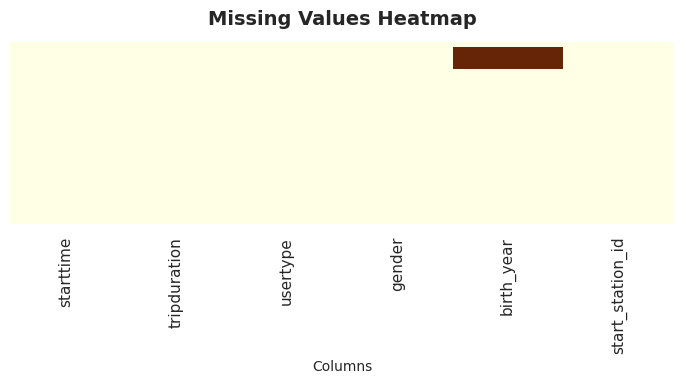

In [6]:
plt.figure(figsize=(7, 4))

sns.heatmap(
    df.isnull(),
    cmap='YlOrBr',
    cbar=False,
    yticklabels=False
)

plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Columns', fontsize=10)
plt.ylabel('')

plt.tight_layout()
plt.show()

In [7]:
df.isnull().sum()

,0
starttime,0
tripduration,0
usertype,0
gender,0
birth_year,410130
start_station_id,0


- Menentukan strategi penanganan missing values

Ditemukan missing values pada kolom birth_year.

Karena kolom ini digunakan untuk menghitung usia pengguna dalam analisis segmentasi, maka baris dengan nilai kosong pada kolom tersebut dihapus. Imputasi tidak dilakukan karena dapat mengganggu distribusi data dan data yang dihapus relatif kecil sehingga tidak berdampak signifikan.

Pendekatan ini dipilih untuk menjaga akurasi distribusi usia dan menghindari bias yang dapat muncul akibat imputasi data.

## 2. Initial Data Exploration

Pada tahap ini dilakukan eksplorasi awal terhadap data sebelum proses cleaning, dengan tujuan untuk memahami distribusi data dan mengidentifikasi potensi anomali.


### 2.1 Distribution Check

- Distribusi trip duration (histogram & boxplot)

Melihat distribusi durasi perjalanan untuk mengidentifikasi pola umum dan potensi outlier.

*   Boxplot

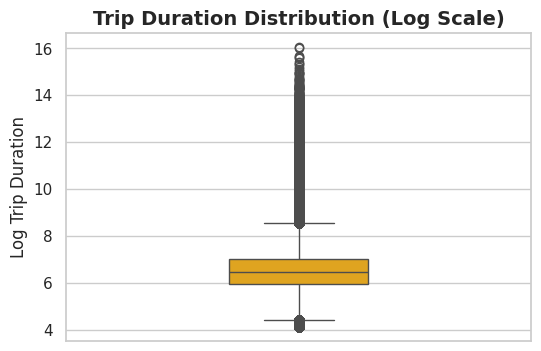

In [8]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    y=np.log1p(df['tripduration']),
    color='#FFB000',
    width=0.3
)

plt.title('Trip Duration Distribution (Log Scale)', fontsize=14, fontweight='bold')
plt.ylabel('Log Trip Duration')
plt.show()

- Identifikasi skewness dan outlier

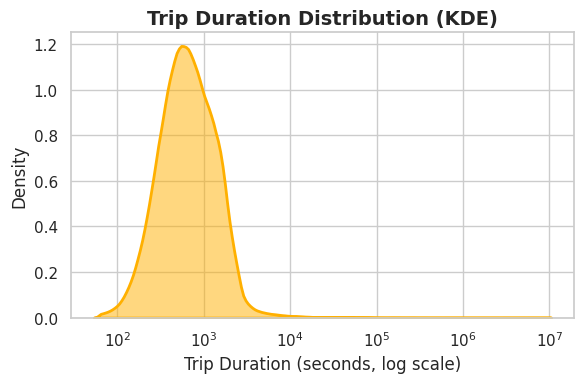

In [9]:
plt.figure(figsize=(6, 4))

sns.kdeplot(
    df['tripduration'],
    log_scale=True,
    fill=True,
    color='#FFB000',
    alpha=0.5,
    linewidth=2
)

plt.title('Trip Duration Distribution (KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Trip Duration (seconds, log scale)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

Berdasarkan visualisasi boxplot dan distribusi KDE dengan skala logaritmik, terlihat bahwa durasi perjalanan memiliki distribusi yang sangat miring ke kanan (right-skewed).

Mayoritas perjalanan berada pada durasi relatif pendek, dengan puncak distribusi di sekitar 5-15 menit. Namun, terdapat sejumlah kecil nilai ekstrem dengan durasi yang sangat tinggi.

Hal ini menunjukkan adanya outlier yang tidak merepresentasikan pola penggunaan normal dan berpotensi mendistorsi analisis, sehingga perlu dilakukan proses data cleaning berbasis logika bisnis.

### 2.2 Extreme Value Inspection

- Menampilkan nilai ekstrem (top duration)

In [10]:
df.sort_values(by='tripduration', ascending=False).head(10)

,starttime,tripduration,usertype,gender,birth_year,start_station_id
2878338,2017-10-07 16:23:15,9340261,Customer,male,1989,3042
135166,2017-04-16 10:23:43,8863767,Customer,unknown,<NA>,3335
69205,2017-10-06 17:35:19,6471279,Subscriber,male,1997,303
3073316,2017-10-18 18:53:53,5977105,Customer,male,1990,3179
2746722,2017-10-07 14:47:14,5954675,Customer,male,1987,383
2720105,2017-10-25 15:37:14,4836816,Customer,female,1987,3052
3377175,2017-05-21 19:18:34,4603308,Subscriber,male,1996,479
295110,2017-08-08 17:53:02,4509256,Customer,unknown,<NA>,336
2707312,2017-10-12 15:16:31,3897730,Customer,male,1988,3070
775489,2015-07-16 21:20:18,3611666,Subscriber,male,1962,377


In [11]:
# Jumlah yang ekstrem (>24 jam)

len(df[df['tripduration'] > 86400])

915

- Analisis percentiles (P90, P95, P99)

In [12]:
df['tripduration'].describe(percentiles=[0.9, 0.95, 0.99])

,tripduration
count,3429745.0
mean,997.323281
std,13721.199622
min,60.0
50%,636.0
90%,1650.0
95%,2057.0
99%,3845.0
max,9340261.0


Ditemukan sebanyak 915 data (±0.03% dari total dataset) dengan durasi perjalanan lebih dari 24 jam.

Jumlah ini sangat kecil dibandingkan keseluruhan data dan tidak sejalan dengan distribusi mayoritas, di mana 99% perjalanan memiliki durasi kurang dari sekitar 64 menit.

Perbedaan yang sangat signifikan antara distribusi utama dan nilai maksimum yang mencapai jutaan detik menunjukkan adanya outlier ekstrem yang tidak mencerminkan pola penggunaan normal.

Nilai-nilai tersebut kemungkinan besar disebabkan oleh anomali atau kesalahan pencatatan data.

Oleh karena itu, data dengan durasi ekstrem akan dihapus pada tahap data cleaning untuk menjaga kualitas dan representativitas analisis.

Fenomena ini juga menunjukkan adanya long-tail distribution yang kuat, di mana sebagian kecil nilai ekstrem berada jauh di luar mayoritas data.

### 2.3 Data Quality Observation

Berdasarkan eksplorasi awal terhadap distribusi data dan nilai ekstrem, ditemukan beberapa isu kualitas data yang perlu diperhatikan:

- Durasi Perjalanan Tidak Masuk Akal

Terdapat sejumlah kecil data dengan durasi perjalanan yang sangat tinggi (lebih dari 24 jam).

Dari total dataset, ditemukan sebanyak 915 data (±0.03%) dengan durasi ekstrem tersebut. Nilai ini sangat tidak sejalan dengan distribusi utama, di mana 99% perjalanan memiliki durasi kurang dari sekitar 64 menit.

Perbedaan yang sangat signifikan ini menunjukkan adanya outlier ekstrem yang kemungkinan besar disebabkan oleh anomali atau kesalahan pencatatan data.

- Distribusi Data Sangat Skewed

Distribusi durasi perjalanan menunjukkan pola right-skewed, di mana sebagian besar data terkonsentrasi pada durasi pendek, dengan ekor panjang pada nilai tinggi.

Kondisi ini mengindikasikan adanya long-tail distribution, di mana sebagian kecil nilai ekstrem berada jauh di luar mayoritas data dan berpotensi mendistorsi metrik analisis, terutama rata-rata.


-  Data Usia Tidak Realistis

Dari kolom birth_year, ditemukan kemungkinan nilai usia yang tidak realistis (misalnya terlalu tua), yang dapat mengindikasikan kesalahan input data.

- Pendekatan Data Cleaning

Berdasarkan temuan di atas, proses data cleaning dilakukan dengan pendekatan kombinasi antara:

1. **Analisis distribusi data (data-driven)**  
   Untuk memahami pola umum dan mengidentifikasi nilai ekstrem berdasarkan distribusi aktual

2. **Logika bisnis (context-aware)**  
   Untuk menentukan batasan yang realistis berdasarkan penggunaan layanan Citi Bike

Dengan pendekatan ini, data yang dihapus benar-benar merupakan data yang tidak representatif terhadap pola penggunaan normal, sehingga hasil analisis tetap akurat dan tidak bias.

Pendekatan ini juga memastikan bahwa data valid tidak terhapus secara berlebihan, sehingga karakteristik utama dataset tetap terjaga.

## 3. Data Cleaning

Proses data cleaning dilakukan berdasarkan hasil eksplorasi sebelumnya, dengan tujuan menghilangkan data yang tidak representatif serta meningkatkan kualitas data untuk analisis.

Pendekatan yang digunakan adalah kombinasi antara analisis distribusi data dan logika bisnis (context-aware).

### 3.1 Handling Missing Values

- Menghapus data dengan birth_year null

Data dengan nilai kosong pada kolom birth_year dihapus karena kolom ini digunakan untuk menghitung usia dalam analisis segmentasi.

In [13]:
print("Before cleaning:", df.shape)

df_clean = df.copy()
df_clean = df_clean.dropna(subset=['birth_year'])

print("After cleaning :", df_clean.shape)
print("Removed rows   :", df.shape[0] - df_clean.shape[0])
print("Removed (%)    :", (df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100)

Before cleaning: (3429745, 6)
After cleaning : (3019615, 6)
Removed rows   : 410130
Removed (%)    : 11.958031865342758


In [14]:
df_clean.isnull().sum()

,0
starttime,0
tripduration,0
usertype,0
gender,0
birth_year,0
start_station_id,0


### 3.2 Removing Duplicates

- Menghapus data duplikat untuk menghindari bias

In [15]:
df_clean = df_clean.drop_duplicates()

print("After removing duplicates:", df_clean.shape)

After removing duplicates: (3019552, 6)


### 3.3 Feature Engineering

- Membuat kolom year, month / hour, age, trip duration (minutes)

In [16]:
df_clean['starttime'] = pd.to_datetime(df_clean['starttime'])

df_clean['year'] = df_clean['starttime'].dt.year
df_clean['month'] = df_clean['starttime'].dt.month
df_clean['hour'] = df_clean['starttime'].dt.hour

df_clean['age'] = 2017 - df_clean['birth_year']
df_clean['trip_minutes'] = df_clean['tripduration'] / 60

### 3.4 Data Consistency Check

- Menghapus: durasi ≤ 0 & nilai tidak logis

In [17]:
df_clean = df_clean[df_clean['tripduration'] > 0]
print("After removing invalid data:", df_clean.shape)

After removing invalid data: (3019552, 11)


### 3.5 Standardization

- Normalisasi usertype

In [18]:
df_clean['usertype'] = df_clean['usertype'].str.lower().str.strip()

- Normalisasi gender

In [19]:
df_clean['gender'] = df_clean['gender'].str.lower().str.strip()


### 3.6 Outlier Handling

- Berdasarkan eksplorasi distribusi

Hasil visualisasi distribusi (boxplot dan KDE dengan skala logaritmik) menunjukkan bahwa durasi perjalanan memiliki distribusi yang sangat miring ke kanan (right-skewed), dengan ekor panjang pada nilai tinggi.

Sebagian besar perjalanan berada pada durasi relatif pendek (sekitar 5-15 menit), sementara terdapat sejumlah kecil nilai ekstrem dengan durasi yang sangat tinggi.

Analisis lebih lanjut menunjukkan bahwa sekitar 915 data (±0.03% dari total dataset) memiliki durasi lebih dari 24 jam, yang jauh di luar pola mayoritas data, di mana 99% perjalanan memiliki durasi kurang dari sekitar 64 menit.

Perbedaan yang sangat signifikan ini mengindikasikan bahwa nilai tersebut merupakan outlier ekstrem yang tidak representatif terhadap perilaku pengguna.

- Berdasarkan logika bisnis

Penentuan batas (threshold) outlier dilakukan menggunakan logika bisnis untuk memastikan relevansi operasional data:

- Durasi < 1 menit dianggap tidak valid (kemungkinan error atau data noise)  
- Durasi > 24 jam dianggap tidak realistis untuk penggunaan layanan Citi Bike  

Pendekatan ini dipilih karena distribusi data yang tidak normal (right-skewed), sehingga metode statistik seperti IQR berpotensi menghapus data yang sebenarnya valid.


- Handling Code

In [20]:
df_clean = df_clean[
    (df_clean['tripduration'] >= 60) &
    (df_clean['tripduration'] <= 86400)
]
print("After removing invalid data:", df_clean.shape)

After removing invalid data: (3018964, 11)


- Kesimpulan

Berdasarkan kedua pendekatan tersebut, dilakukan filtering untuk menghapus data di luar batas yang telah ditentukan, sehingga data yang digunakan dalam analisis lebih representatif dan tidak bias.

### 3.7 Cleaning Age

Cleaning pada variabel usia dilakukan untuk memastikan bahwa data yang digunakan dalam analisis segmentasi tetap representatif dan realistis.

- Justifikasi berdasarkan distribusi & domain knowledge

#### 1. Berdasarkan eksplorasi distribusi
Distribusi usia menunjukkan bahwa mayoritas pengguna berada pada rentang usia produktif, dengan nilai rata-rata sekitar 41 tahun dan median 40 tahun.

Sebagian besar pengguna berada pada rentang usia sekitar 32-50 tahun (interquartile range), yang menunjukkan bahwa distribusi cukup terpusat pada kelompok usia dewasa aktif.

Namun, terdapat sejumlah kecil nilai ekstrem pada usia yang sangat tinggi, yang tidak sejalan dengan pola mayoritas data.

Nilai usia yang terlalu tinggi ini mengindikasikan kemungkinan kesalahan input pada kolom birth_year, seperti tahun lahir yang tidak valid.



#### 2. Berdasarkan domain knowledge
Secara umum, pengguna layanan sepeda seperti Citi Bike didominasi oleh kelompok usia produktif yang memiliki mobilitas tinggi.

Usia di atas 80-90 tahun dianggap kurang realistis untuk pola penggunaan normal layanan ini, sehingga nilai tersebut dikategorikan sebagai data yang tidak representatif.

Oleh karena itu, dilakukan filtering untuk memastikan bahwa data yang digunakan dalam analisis tetap relevan dan mencerminkan perilaku pengguna sebenarnya.


- Implementasi Filtering

In [21]:
before = len(df_clean)

df_clean = df_clean[df_clean['age'].between(10, 90)]

after = len(df_clean)

print("Before cleaning age:", before)
print("After cleaning age :", after)
print("Removed            :", before - after)

Before cleaning age: 3018964
After cleaning age : 3017464
Removed            : 1500


### 3.8 Data Validation

Setelah proses data cleaning, dilakukan validasi untuk memastikan bahwa data yang dihasilkan sudah lebih representatif dan siap digunakan untuk analisis.

- Validasi distribusi setelah cleaning

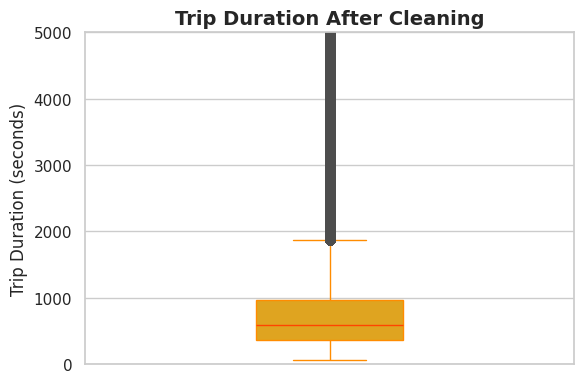

In [22]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    y=df_clean['tripduration'],
    color='#FFB000',
    width=0.3,
    boxprops=dict(edgecolor='#FF8C00'),
    whiskerprops=dict(color='#FF8C00'),
    capprops=dict(color='#FF8C00'),
    medianprops=dict(color='#FF4500')
)

plt.title('Trip Duration After Cleaning', fontsize=14, fontweight='bold')
plt.ylabel('Trip Duration (seconds)')
plt.xlabel('')

plt.ylim(0, 5000)
plt.tight_layout()
plt.show()

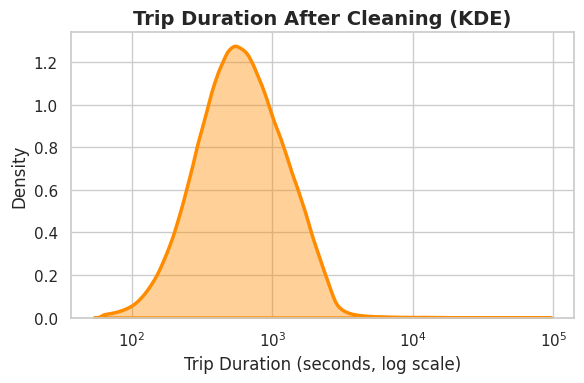

In [23]:
plt.figure(figsize=(6, 4))

sns.kdeplot(
    df_clean['tripduration'],
    log_scale=True,
    fill=True,
    color='#FF8C00',
    alpha=0.4,
    linewidth=2.5
)

plt.title('Trip Duration After Cleaning (KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Trip Duration (seconds, log scale)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

Distribusi durasi perjalanan setelah cleaning menunjukkan pola yang lebih stabil, dengan berkurangnya nilai ekstrem yang sebelumnya mendistorsi data.

Mayoritas data tetap berada pada rentang durasi yang relevan, sehingga pola penggunaan menjadi lebih jelas dan mudah diinterpretasikan.

- Perbandingan jumlah data sebelum vs sesudah

In [24]:
before = len(df)
after = len(df_clean)

print("Before cleaning:", before)
print("After cleaning :", after)
print("Removed data   :", before - after)
print("Removed (%)    :", round((before - after) / before * 100, 4), "%")

Before cleaning: 3429745
After cleaning : 3017464
Removed data   : 412281
Removed (%)    : 12.0207 %


Dilakukan perbandingan jumlah data sebelum dan sesudah proses cleaning untuk mengevaluasi dampak dari proses pembersihan data.

Hasil menunjukkan bahwa sekitar 12.02% data dihapus selama proses cleaning. Persentase ini relatif signifikan, yang menunjukkan bahwa terdapat cukup banyak data yang tidak memenuhi kriteria kualitas, terutama terkait nilai ekstrem dan usia yang tidak realistis.

Meskipun demikian, data yang dihapus merupakan data yang tidak representatif terhadap pola penggunaan normal, sehingga penghapusan ini diperlukan untuk meningkatkan kualitas analisis.

Distribusi setelah cleaning tetap mempertahankan bentuk utama (right-skewed), yang merupakan karakteristik alami dari data penggunaan Citi Bike, namun dengan intensitas outlier yang jauh berkurang.

Dengan demikian, proses cleaning berhasil mengurangi noise dan meningkatkan representativitas data tanpa mengubah pola utama yang mendasari perilaku pengguna.

## 4. Exploratory Data Analysis

### 4.1 Distribution Analysis

Analisis distribusi dilakukan untuk memahami pola umum dari durasi perjalanan dan karakteristik pengguna berdasarkan usia setelah proses data cleaning.

- Distribusi trip duration

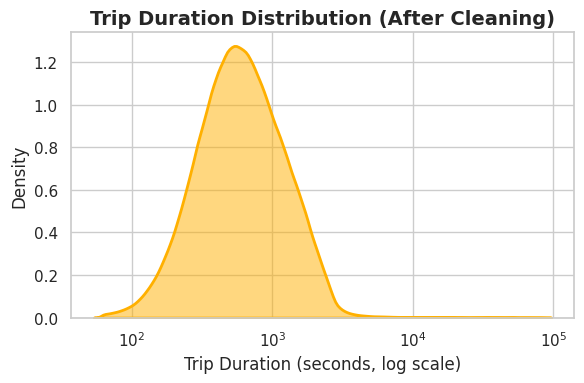

In [25]:
plt.figure(figsize=(6, 4))

sns.kdeplot(
    df_clean['tripduration'],
    log_scale=True,
    fill=True,
    color='#FFB000',
    alpha=0.5,
    linewidth=2
)

plt.title('Trip Duration Distribution (After Cleaning)', fontsize=14, fontweight='bold')
plt.xlabel('Trip Duration (seconds, log scale)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

Distribusi durasi perjalanan setelah proses cleaning menunjukkan pola yang lebih terpusat, dengan sebagian besar perjalanan berada pada durasi relatif pendek.

Puncak distribusi berada pada rentang sekitar 5-15 menit, yang menunjukkan bahwa Citi Bike lebih sering digunakan untuk perjalanan jarak pendek, seperti aktivitas komuter harian.

Dibandingkan sebelum cleaning, distribusi kini terlihat lebih halus dan terkonsentrasi, dengan berkurangnya pengaruh nilai ekstrem yang sebelumnya menyebabkan ekor distribusi menjadi sangat panjang.

Meskipun distribusi masih menunjukkan kecenderungan right-skewed, bentuknya kini lebih representatif terhadap pola penggunaan sebenarnya, tanpa distorsi dari outlier ekstrem.

- Distribusi usia

In [26]:
df_clean['age'].describe()

,age
count,3017464.0
mean,39.007175
std,11.605288
min,16.0
25%,30.0
50%,36.0
75%,47.0
max,90.0


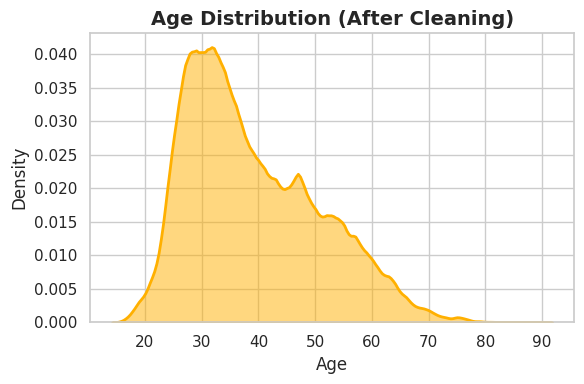

In [27]:
plt.figure(figsize=(6, 4))

sns.kdeplot(
    df_clean['age'],
    fill=True,
    color='#FFB000',
    alpha=0.5,
    linewidth=2
)

plt.title('Age Distribution (After Cleaning)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

Distribusi usia setelah proses cleaning menunjukkan pola yang cukup terpusat pada kelompok usia dewasa produktif.

Nilai rata-rata usia pengguna adalah sekitar 41.7 tahun, dengan median 40 tahun, yang menunjukkan bahwa distribusi relatif seimbang di sekitar usia dewasa.

Sebagian besar pengguna berada pada rentang usia 32-50 tahun (interquartile range), dengan konsentrasi tertinggi pada usia sekitar 30-40 tahun.

Distribusi terlihat lebih bersih dan terkonsentrasi setelah proses cleaning, dengan berkurangnya nilai usia ekstrem yang sebelumnya tidak realistis.

Jumlah pengguna pada usia yang lebih tinggi (di atas 60 tahun) relatif lebih sedikit, yang konsisten dengan karakteristik layanan transportasi berbasis aktivitas fisik.

Hal ini mengindikasikan bahwa Citi Bike tertama digunakan oleh kelompok usia aktif dengan mobilitas tinggi, yang berpotensi menjadi target utama dalam strategi pengembangan layanan.

### 4.2 Key Metrics Analysis

Analisis dilakukan terhadap dua metrik utama, yaitu jumlah perjalanan dan rata-rata durasi perjalanan, untuk memahami kinerja layanan Citi Bike selama periode 2015-2017.

- Jumlah trip per tahun (2015-2017)

In [28]:
trip_per_year = df_clean.groupby('year').size().reset_index(name='total_trip')
trip_per_year['growth_%'] = trip_per_year['total_trip'].pct_change() * 100
trip_per_year

,year,total_trip,growth_%
0,2015,860915,NaN
1,2016,895825,4.054988
2,2017,1260724,40.733291


Jumlah perjalanan menunjukkan tren peningkatan yang konsisten selama periode 2015-2017.

Pada tahun 2016, jumlah perjalanan meningkat sbesar sekitar 4.05% dibandingkan tahun sebelumnya, yang menunjukkan pertumbuhan yang relatif moderat.

Namun, pada tahun 2017 terjadi lonjakan signifikan dengan pertumbuhan sebesar sekitar 40.73%, menunjukkan percepatan adopsi layanan Citi Bike dalam skala yang jauh lebih besar.

Lonjakan ini mengindikasikan adanya peningkatan popularitas layanan, yang kemungkinan didorong oleh faktor seperti ekspansi layanan, peningkatan jumlah pengguna, atau peningkatan kebutuhan transportasi alternatif.

Perbedaan tingkat pertumbuhan yang signifikan antara tahun 2016 dan 2017 menunjukkan adanya momentum pertumbuhan yang kuat, yang berpotensi menjadi titik penting dalam perkembangan layanan Citi Bike.

- Rata-rata durasi perjalanan

In [29]:
duration_per_year = df_clean.groupby('year')['trip_minutes'].mean().reset_index()
duration_per_year

,year,trip_minutes
0,2015,12.852988
1,2016,13.089475
2,2017,13.202304


Rata-rata durasi perjalanan menunjukkan tren peningkatan yang sangat ringan selama periode 2015-2017.

Durasi rata-rata meningkat dari sekitar 12.85 menit pada tahun 2015 menjadi 13.09 menit pada tahun 2016, dan sedikit meningkat lagi menjadi 13.20 menit pada tahun 2017.

Peningkatan ini relatif kecil dibandingkan dengan pertumbuhan jumlah perjalanan, sehingga dapat dikatakan bahwa pola penggunaan layanan Citi Bike cenderung stabil.

Mayoritas pengguna tetap menggunakan layanan untuk perjalanan jarak pendek, tanpa perubahan signifikan dalam durasi penggunaan.

- Analisis tren (growth / stabilitas)

Peningkatan jumlah perjalanan yang sangat signifikan, terutama pada tahun 2017, tidak diikuti oleh peningkatan yang berarti pada durasi perjalanan.

Hal ini menunjukkan bahwa pertumbuhan layanan Citi Bike didorong oleh peningkatan jumlah pengguna atau frekuensi penggunaan, bukan perubahan dalam perilaku pengguna.

Dengan kata lain, lebih banyak perjalanan terjadi, namun dengan pola penggunaan yang tetap konsisten, yaitu perjalanan berdurasi pendek.

Temuan ini mengindikasikan bahwa Citi Bike semakin berperan sebagai sarana transportasi harian yang praktis, terutama untuk kebutuhan mobilitas jarak pendek.

### 4.3 User Segmentation

Analisis segmentasi pengguna dilakukan untuk memahami perbedaan pola penggunaan berdasarkan tipe pengguna, gender, dan usia.

- Berdasarkan user type

In [30]:
usertype_summary = df_clean.groupby('usertype').agg({
    'tripduration': 'count',
    'trip_minutes': 'mean'
}).rename(columns={
    'tripduration': 'total_trip',
    'trip_minutes': 'avg_duration'
}).reset_index()

usertype_summary

,usertype,total_trip,avg_duration
0,customer,34098,27.449427
1,subscriber,2983366,12.904786


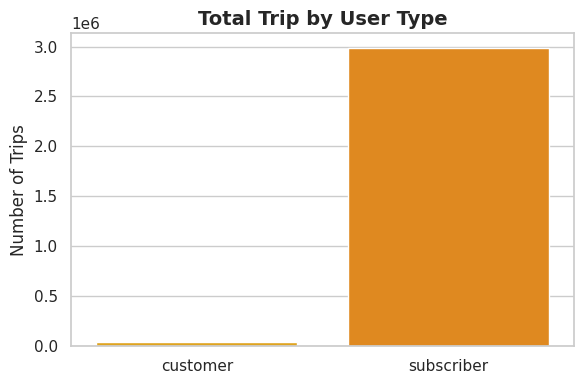

In [31]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=usertype_summary,
    x='usertype',
    y='total_trip',
    hue='usertype',
    palette=['#FFB000', '#FF8C00'],
    legend=False
)

plt.title('Total Trip by User Type', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

Segmentasi berdasarkan tipe pengguna menunjukkan bahwa Subscriber mendominasi secara signifikan, dengan total lebih dari 2.9 juta perjalanan, dibandingkan Customer yang hanya sekitar 34 ribu perjalanan.

Namun, terdapat perbedaan yang cukup mencolok pada durasi perjalanan, di mana Customer memiliki rata-rata durasi yang jauh lebih panjang (±27.45 menit) dibandingkan Subscriber (±12.90 menit).

Hal ini mengindikasikan bahwa:
- Subscriber cenderung menggunakan Citi Bike untuk kebutuhan rutin seperti commuting, dengan durasi perjalanan yang lebih pendek
- Customer lebih cenderung menggunakan layanan untuk keperluan rekreasi atau penggunaan sesekali, sehingga durasi perjalanan lebih panjang

- Berdasarkan gender

In [32]:
gender_summary = df_clean.groupby('gender').agg({
    'tripduration': 'count',
    'trip_minutes': 'mean'
}).rename(columns={
    'tripduration': 'total_trip',
    'trip_minutes': 'avg_duration'
}).reset_index()

gender_summary

,gender,total_trip,avg_duration
0,female,741208,14.666607
1,male,2267450,12.537685
2,unknown,8806,15.454291


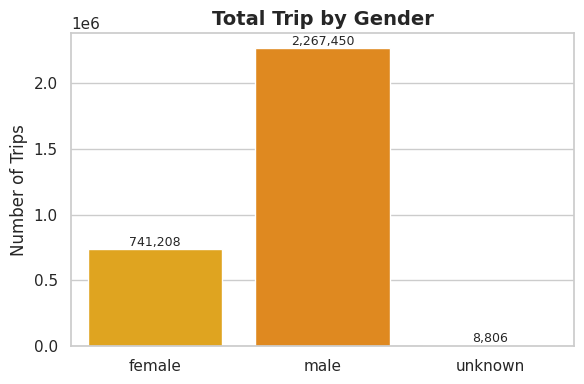

In [33]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=gender_summary,
    x='gender',
    y='total_trip',
    hue='gender',
    palette=['#FFB000', '#FF8C00', '#FFC04D'],
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Total Trip by Gender', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

Distribusi pengguna berdasarkan gender menunjukkan bahwa pengguna laki-laki mendominasi jumlah perjalanan, dengan total sekitar 2.26 juta trip, dibandingkan perempuan sekitar 741 ribu trip.

Meskipun demikian, pengguna perempuan memiliki rata-rata durasi perjalanan yang sedikit lebih tinggi (±14.67 menit) dibandingkan laki-laki (±12.54 menit).

Hal ini menunjukkan bahwa:
- Laki-laki lebih sering menggunakan layanan (frekuensi tinggi)
- Perempuan cenderung memiliki durasi penggunaan yang sedikit lebih lama

Perbedaan ini dapat mengindikasikan variasi dalam tujuan penggunaan atau pola perjalanan antar gender, meskipun secara umum tidak terlalu signifikan.

- Berdasarkan age group

In [34]:
bins = [10, 20, 30, 40, 50, 60, 90]
labels = ['<20', '20-30', '30-40', '40-50', '50-60', '60+']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels)
age_summary = df_clean.groupby('age_group').agg({ 'tripduration': 'count', 'trip_minutes': 'mean' }).rename(columns={ 'tripduration': 'total_trip', 'trip_minutes': 'avg_duration' }).reset_index()
age_summary

/tmp/ipykernel_15415/2328852334.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df_clean.groupby('age_group').agg({ 'tripduration': 'count', 'trip_minutes': 'mean' }).rename(columns={ 'tripduration': 'total_trip', 'trip_minutes': 'avg_duration' }).reset_index()


,age_group,total_trip,avg_duration
0,<20,30365,13.27971
1,20-30,808035,12.908307
2,30-40,1000862,12.914395
3,40-50,617272,13.085851
4,50-60,406886,13.454845
5,60+,154044,13.791015


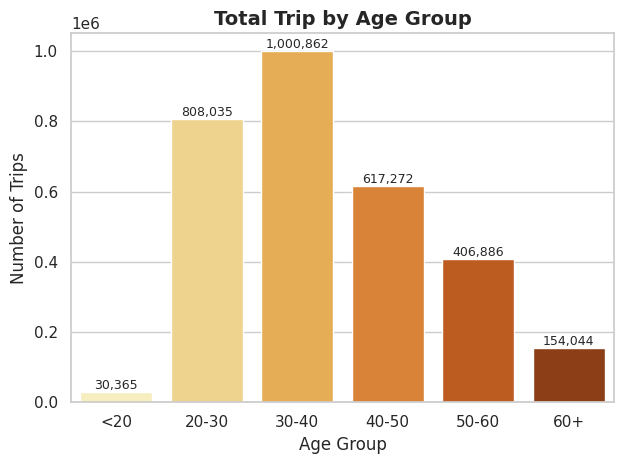

In [35]:
ax = sns.barplot(
    data=age_summary,
    x='age_group',
    y='total_trip',
    hue='age_group',
    palette='YlOrBr',
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Total Trip by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Trips')

plt.tight_layout()
plt.show()

Segmentasi berdasarkan usia menunjukkan bahwa kelompok usia 30-40 tahun merupakan pengguna dengan jumlah perjalanan tertinggi, diikuti oleh kelompok usia 20-30 tahun.

Hal ini menegaskan bahwa layanan Citi Bike paling banyak digunakan oleh kelompok usia produktif.

Dari sisi durasi, terlihat adanya tren peningkatan seiring bertambahnya usia, di mana kelompok usia yang lebih tua cenderung memiliki durasi perjalanan yang sedikit lebih lama.

Sebagai contoh, kelompok usia 60+ memiliki rata-rata durasi sekitar 13.79 menit, lebih tinggi dibandingkan kelompok usia 20-30 yang sekitar 12.91 menit.

Hal ini mengindikasikan bahwa:
- Pengguna muda lebih banyak melakukan perjalanan cepat (commuting)
- Pengguna yang lebih tua cenderung menggunakan layanan dengan tempo yang lebih santai atau untuk keperluan non-rutin

### 4.4 Regional Analysis

Analisis regional dilakukan untuk mengidentifikasi stasiun dengan tingkat penggunaan tertinggi serta area dengan permintaan yang tinggi.

- Analisis station dengan trip tertinggi

In [36]:
top_station = df_clean.groupby('start_station_id').size().reset_index(name='total_trip')

top_station = top_station.sort_values(by='total_trip', ascending=False).head(10)

top_station

,start_station_id,total_trip
294,519,32709
213,435,24501
273,497,23409
184,402,21471
205,426,19704
83,293,19598
266,490,19348
79,285,18776
78,284,18193
253,477,17936


/tmp/ipykernel_15415/3213390576.py:7: UserWarning: 
The palette list has fewer values (8) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


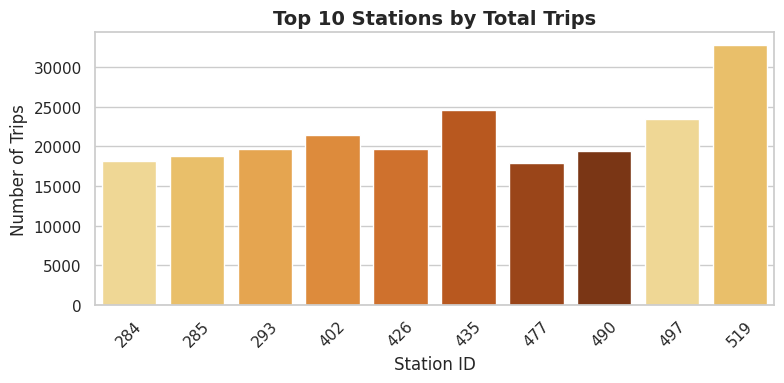

In [37]:
top_station_sorted = top_station.sort_values(by='total_trip')

palette = sns.color_palette("YlOrBr", n_colors=len(top_station_sorted))[2:]

plt.figure(figsize=(8, 4))

sns.barplot(
    data=top_station_sorted,
    x='start_station_id',
    y='total_trip',
    hue='start_station_id',
    palette=palette,
    legend=False
)

plt.title('Top 10 Stations by Total Trips', fontsize=14, fontweight='bold')
plt.xlabel('Station ID')
plt.ylabel('Number of Trips')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Analisis menunjukkan bahwa beberapa stasiun memiliki jumlah perjalanan yang jauh lebih tinggi dibandingkan stasiun lainnya.

Sebagai contoh, stasiun dengan ID 519 mencatat jumlah perjalanan tertinggi dengan lebih dari 32 ribu trip, diikuti oleh stasiun lainnya seperti 435 dan 497 dengan lebih dari 23 ribu perjalanan.

Perbedaan yang cukup signifikan ini menunjukkan bahwa penggunaan Citi Bike tidak merata, melainkan terkonsentrasi pada beberapa stasiun tertentu.

- Identifikasi area dengan demand tinggi

In [38]:
high_demand = df_clean.groupby('start_station_id').size().reset_index(name='total_trip')

high_demand['category'] = pd.qcut(high_demand['total_trip'], q=3, labels=['Low', 'Medium', 'High'])

high_demand

,start_station_id,total_trip,category
0,72,7317,High
1,79,5874,High
2,82,2230,Medium
3,83,2787,Medium
4,116,11653,High
...,...,...,...
840,3648,62,Low
841,3649,15,Low
842,3650,8,Low
843,3653,4,Low


Klasifikasi stasiun berdasarkan tingkat demand menunjukkan adanya kelompok stasiun dengan kategori tinggi, menengah, dan rendah.

Stasiun dengan kategori demand tinggi memiliki jumlah perjalanan yang jauh di atas rata-rata, yang mengindikasikan lokasi dengan aktivitas mobilitas tinggi, seperti area komuter, pusat bisnis, atau titik transportasi strategis.

Sebaliknya, terdapat sejumlah besar stasiun dengan kategori demand rendah, yang menunjukkan adanya ketimpangan distribusi penggunaan antar lokasi.

- Kesimpulan

Secara keseluruhan, distribusi penggunaan Citi Bike menunjukkan pola yang tidak merata, dengan konsentrasi tinggi pada beberapa stasiun tertentu.

Hal ini mengindikasikan bahwa permintaan layanan sangat dipengaruhi oleh lokasi, di mana stasiun-stasiun tertentu menjadi pusat aktivitas pengguna.

Temuan ini menunjukkan adanya peluang untuk:
- Mengoptimalkan distribusi sepeda di stasiun dengan demand tinggi untuk menghindari kekurangan unit
- Mengevaluasi strategi peningkatan penggunaan pada stasiun dengan demand rendah

## 5. Insights & Findings

### 5.1 Performance Insight

- Tren pertumbuhan jumlah perjalanan

Jumlah perjalanan menunjukkan tren peningkatan yang konsisten selama periode 2015-2017.

Pertumbuhan pada tahun 2016 relatif moderat (±4.05%), namun terjadi lonjakan signifikan pada tahun 2017 dengan pertumbuhan sekitar ±40.73%.

Hal ini menunjukkan adanya percepatan adopsi layanan Citi Bike, yang mengindikasikan peningkatan popularitas dan kebutuhan terhadap layanan transportasi berbasis sepeda.


- Pola durasi perjalanan

Rata-rata durasi perjalanan relatif stabil selama periode analisis, dengan peningkatan yang sangat kecil dari sekitar 12.85 menit pada tahun 2015 menjadi 13.20 menit pada tahun 2017.

Distribusi durasi tetap menunjukkan pola dominan pada perjalanan jarak pendek, yang mengindikasikan bahwa Citi Bike terutama digunakan untuk kebutuhan mobilitas harian seperti commuting.


- Ringkasan Kinerja

Secara keseluruhan, Citi Bike mengalami pertumbuhan signifikan dalam jumlah perjalanan tanpa perubahan berarti pada durasi penggunaan.

Hal ini menunjukkan bahwa pertumbuhan layanan didorong oleh peningkatan jumlah pengguna atau frekuensi penggunaan, bukan perubahan perilaku pengguna.

Dengan kata lain, lebih banyak orang menggunakan layanan ini, namun untuk tujuan yang sama, yaitu perjalanan jarak pendek.

### 5.2 User Behavior Insight

#### - Pola Penggunaan Berdasarkan User Type

Segmentasi menunjukkan bahwa sebagian besar perjalanan dilakukan oleh pengguna bertipe Subscriber, dengan jumlah yang jauh lebih besar dibandingkan Customer.

Namun, Customer memiliki rata-rata durasi perjalanan yang jauh lebih panjang (±27.45 menit) dibandingkan Subscriber (±12.90 menit).

Hal ini mengindikasikan adanya dua pola penggunaan utama:
1. Subscriber menggunakan Citi Bike untuk kebutuhan rutin seperti commuting, dengan frekuensi tinggi dan durasi pendek
2. Customer cenderung menggunakan layanan untuk keperluan rekreasi atau penggunaan sesekali, dengan durasi yang lebih panjang


#### - Pola Penggunaan Berdasarkan Gender

Pengguna laki-laki mendominasi jumlah perjalanan, namun pengguna perempuan memiliki rata-rata durasi perjalanan yang sedikit lebih tinggi.

Hal ini menunjukkan bahwa:
1. Laki-laki lebih sering menggunakan layanan (high frequency usage)
2. Perempuan cenderung memiliki durasi penggunaan yang sedikit lebih lama

Meskipun demikian, perbedaan durasi antar gender tidak terlalu signifikan, sehingga pola penggunaan secara umum relatif serupa.


#### - Pola Penggunaan Berdasarkan Usia

Mayoritas pengguna berada pada kelompok usia produktif (20-40 tahun), dengan kontribusi perjalanan tertinggi berasal dari kelompok usia 30-40 tahun.

Dari sisi durasi, terdapat kecenderungan peningkatan seiring bertambahnya usia, di mana pengguna dengan usia lebih tinggi cenderung memiliki durasi perjalanan yang sedikit lebih lama.

Hal ini mengindikasikan bahwa:
1. Pengguna usia muda lebih banyak melakukan perjalanan cepat (commuting)
2. Pengguna usia lebih tua cenderung menggunakan layanan dengan tempo yang lebih santai atau untuk keperluan non-rutin

#### - Ringkasan Perilaku Pengguna

Secara keseluruhan, terdapat dua segmen utama pengguna Citi Bike:

1. **Commuter (Subscriber, usia produktif)**  
   Menggunakan layanan secara rutin dengan durasi pendek

2. **Recreational User (Customer, usia lebih beragam)**  
   Menggunakan layanan secara tidak rutin dengan durasi lebih panjang

Pemahaman terhadap kedua segmen ini menjadi kunci dalam menentukan strategi pengembangan layanan ke depan.

### 5.3 Key Observations

Berdasarkan hasil analisis kinerja dan perilaku pengguna, berikut beberapa rekomendasi strategis yang dapat dilakukan oleh Citi Bike untuk tahun 2018:


#### 1. Optimasi Kapasitas pada Area dengan Demand Tinggi

Temuan menunjukkan bahwa penggunaan Citi Bike terkonsentrasi pada beberapa stasiun tertentu dengan jumlah perjalanan yang jauh lebih tinggi dibandingkan stasiun lainnya.

**Rekomendasi:**
- Menambah jumlah sepeda dan docking station pada area dengan demand tinggi
- Mengoptimalkan redistribusi sepeda untuk menghindari kekurangan unit pada jam sibuk

#### 2. Meningkatkan Aktivasi pada Area dengan Demand Rendah

Terdapat sejumlah stasiun dengan tingkat penggunaan yang rendah, yang mengindikasikan potensi underutilization.

**Rekomendasi:**
- Melakukan promosi atau insentif pada area dengan demand rendah
- Mengkaji ulang lokasi stasiun untuk memastikan kesesuaian dengan kebutuhan pengguna

#### 3. Memperkuat Segmentasi Commuter (Subscriber)

Sebagian besar pengguna merupakan Subscriber dengan pola penggunaan rutin dan durasi pendek.

**Rekomendasi:**
- Mengembangkan program loyalitas untuk meningkatkan retensi pengguna
- Menyediakan paket langganan yang lebih fleksibel sesuai kebutuhan pengguna harian


#### 4. Mengoptimalkan Segmen Recreational User (Customer)

Customer memiliki durasi perjalanan yang lebih panjang, yang menunjukkan potensi penggunaan untuk rekreasi.

**Rekomendasi:**
- Mengembangkan paket penggunaan berbasis durasi (misalnya paket harian atau wisata)
- Menyediakan rute atau rekomendasi perjalanan untuk meningkatkan pengalaman pengguna


#### 5. Targeting Berdasarkan Demografi

Mayoritas pengguna berasal dari kelompok usia produktif, dengan perbedaan pola penggunaan antar gender dan usia.

**Rekomendasi:**
- Menyesuaikan strategi pemasaran untuk kelompok usia produktif sebagai target utama
- Mengembangkan kampanye yang lebih inklusif untuk meningkatkan partisipasi pengguna perempuan


#### 6. Fokus pada Pertumbuhan Berkelanjutan

Pertumbuhan jumlah perjalanan yang signifikan tidak diikuti oleh perubahan perilaku penggunaan, yang menunjukkan stabilitas pola penggunaan.

**Rekomendasi:**
- Mempertahankan fokus pada layanan untuk perjalanan jarak pendek (commuting)
- Mengembangkan infrastruktur yang mendukung peningkatan volume pengguna tanpa mengorbankan kualitas layanan

#### Kesimpulan
Citi Bike memiliki peluang besar untuk terus berkembang dengan memanfaatkan pertumbuhan jumlah pengguna dan memahami perbedaan perilaku antar segmen.

Strategi yang berfokus pada optimasi operasional, segmentasi pengguna, dan peningkatan pengalaman pelanggan akan menjadi kunci dalam meningkatkan performa layanan di tahun 2018.

### Strategi Utama untuk 2018
- Mengoptimalkan kapasitas pada stasiun dengan demand tinggi untuk menghindari kekurangan unit dan meningkatkan ketersediaan layanan
- Meningkatkan utilisasi pada stasiun dengan demand rendah melalui promosi atau penyesuaian lokasi
- Memperkuat segmen commuter (Subscriber) sebagai pengguna utama melalui peningkatan layanan dan program loyalitas
- Mengembangkan potensi segmen recreational (Customer) melalui penawaran berbasis durasi dan pengalaman pengguna
- Menyesuaikan strategi pemasaran berdasarkan demografi pengguna untuk meningkatkan akuisisi dan engagement

##